In [1]:
# TransferLearning Architecture
#Pretrained models
#vgg16 for binary-classification


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import tensorflow
from tensorflow import keras

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, ReLU, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.activations import relu, softmax, sigmoid

In [5]:
#using transfer learning techinques
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19


In [6]:
image_size=[224,224]

In [8]:
train_data='/content/drive/MyDrive/Deep_Learning/CNN/Binary_cnn/training_data'
test_data='/content/drive/MyDrive/Deep_Learning/CNN/Binary_cnn/testing_data'

In [10]:
vgg16 = VGG16(input_shape=image_size+[3],
              weights='imagenet',
              include_top = False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [12]:
for layers in vgg16.layers: # dont distrub original weights
  layers.trainable=False

In [14]:
x=Flatten()(vgg16.output)

In [15]:
predict = Dense(1,activation='sigmoid')(x)

#for multilabel
#predict = Dense(74,activation='softmax')(x)

In [17]:
model = Model(inputs=vgg16.inputs,outputs=predict)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [22]:
training_data=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 horizontal_flip=True,
                                 zoom_range=0.2)

In [23]:
testing_data = ImageDataGenerator(rescale=1./255)

In [25]:
train = training_data.flow_from_directory(
    train_data,
    target_size=(224,224),
    batch_size=4,
    class_mode='binary'
)

Found 103 images belonging to 3 classes.


In [26]:
test =testing_data.flow_from_directory(
    test_data,
    target_size=(224,224),
    batch_size=4,
    class_mode='binary'
)

Found 21 images belonging to 2 classes.


In [28]:
model.fit(train,
          epochs=50)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.3529 - loss: -8.3237
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.4866 - loss: -36.8579
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4717 - loss: -65.5761
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4100 - loss: -104.1703
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4052 - loss: -141.6237
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.4773 - loss: -155.1776
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4568 - loss: -190.3170
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.5357 - loss: -188.0794
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.4592 - loss: -251.3254
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5190 - loss: -253.7986
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5134 - loss: -284.8668
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━

In [29]:
model.history.history.keys()

dict_keys(['accuracy', 'loss'])

In [34]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [35]:
classes={0:'Day',1:'Night'}
for i in classes.items():
  print(i)


(0, 'Day')
(1, 'Night')


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[1.]]
[0]
Day


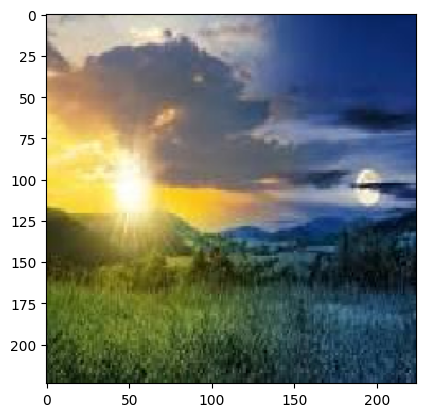

In [36]:
#testing
image_path='/content/drive/MyDrive/Deep_Learning/CNN/google.jpg'
new_img = load_img(image_path,target_size=(224,224))
img = img_to_array(new_img)
img = np.expand_dims(img,axis=0)
prediction=model.predict(img)
print(prediction)
prediction=np.argmax(prediction,axis=1)
print(prediction)
print(classes[prediction[0]])
plt.imshow(new_img)

"""For multilabel classification we use output as a how many number of classes we have and activation='softmax'"""